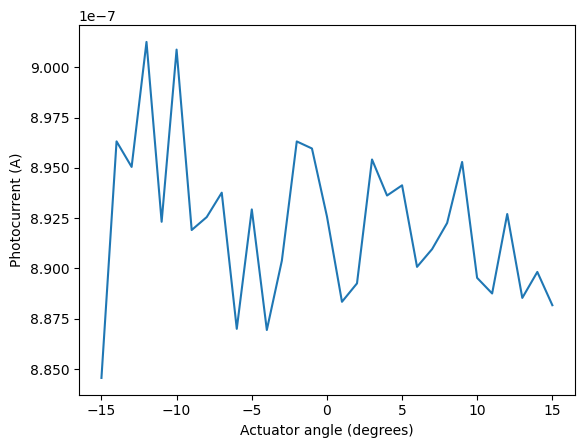

In [1]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\Flash Lamp\FlashLamp1.txt",
                  delimiter=',',
                  usecols=(0,1))

angle = data[:, 0]
photocurrent = data[:, 1]

plt.plot(angle, photocurrent)
plt.xlabel('Actuator angle (degrees)')
plt.ylabel('Photocurrent (A)')
plt.show()

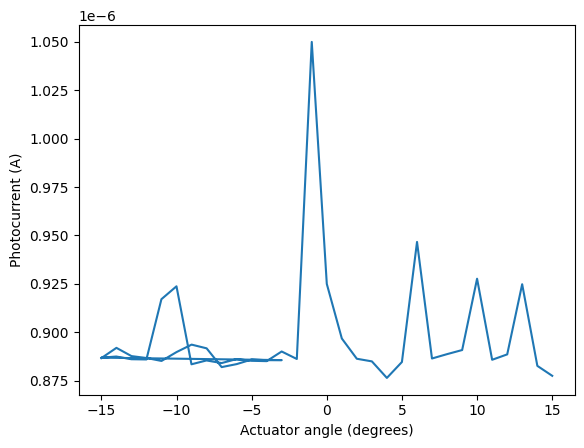

In [2]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\Flash Lamp\FlashLamp2.txt",
                  delimiter=',',
                  usecols=(0,1))

angle = data[:, 0]
photocurrent = data[:, 1]

plt.plot(angle, photocurrent)
plt.xlabel('Actuator angle (degrees)')
plt.ylabel('Photocurrent (A)')
plt.show()

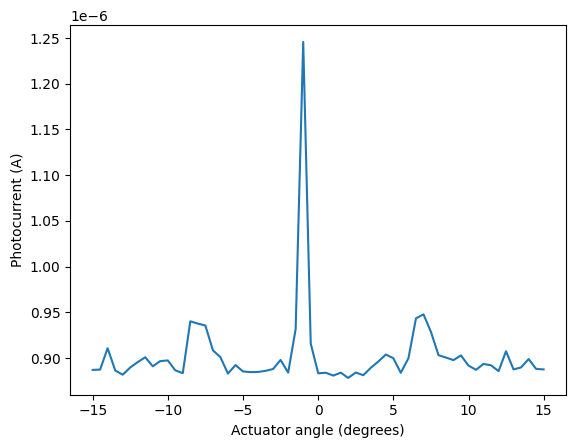

In [3]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\Flash Lamp\FlashLamp3.txt", delimiter=',', usecols=(0,1))

angle = data[:, 0]
photocurrent = data[:, 1]

plt.plot(angle, photocurrent)
plt.xlabel('Actuator angle (degrees)')
plt.ylabel('Photocurrent (A)')
plt.show()

   Pic 1 : λ = 324.9 nm, Intensité = 9.08e-07 A
   Pic 2 : λ = -311.1 nm, Intensité = 9.11e-07 A
   Pic 3 : λ = 1.1 nm, Intensité = 1.25e-06 A


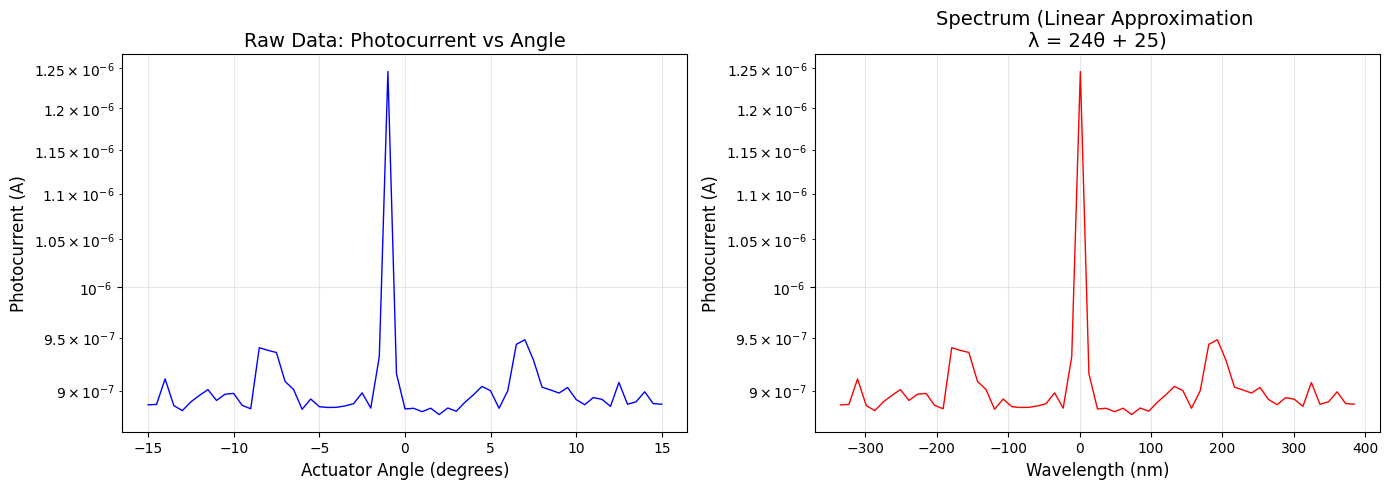

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def angle_to_wavelength_linear(theta_deg):
    return 24 * theta_deg + 25

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\3. Flash Lamp\FlashLamp3.txt",
                  delimiter=',',
                  usecols=(0, 1))

angle = data[:, 0]
photocurrent = data[:, 1]

wavelength_linear = angle_to_wavelength_linear(angle)

peaks, _ = find_peaks(photocurrent, distance=20, prominence=1e-10)

if len(peaks) == 0:
    print("Aucun pic détecté. Essaie de réduire 'prominence'.")
else:
    peak_heights = photocurrent[peaks]

    top3_indices = peaks[np.argsort(peak_heights)[-3:]]

    top3_angles = angle[top3_indices]
    top3_wavelengths = angle_to_wavelength_linear(top3_angles)
    top3_heights = photocurrent[top3_indices]

    for i, (lam, intens) in enumerate(zip(top3_wavelengths, top3_heights), 1):
        print(f"   Pic {i} : λ = {lam:.1f} nm, Intensité = {intens:.2e} A")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Données brutes (angle)
ax1.plot(angle, photocurrent, 'b-', linewidth=1)
ax1.set_xlabel('Actuator Angle (degrees)', fontsize=12)
ax1.set_ylabel('Photocurrent (A)', fontsize=12)
ax1.set_title('Raw Data: Photocurrent vs Angle', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Graphique 2 : Spectre avec approximation linéaire
ax2.plot(wavelength_linear, photocurrent, 'r-', linewidth=1)
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Photocurrent (A)', fontsize=12)
ax2.set_title('Spectrum (Linear Approximation \nλ = 24θ + 25'')', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

calibrated_spectrum_data = np.column_stack((wavelength_linear, photocurrent))

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\3. Flash Lamp\calibrated_spectrum_flashlamp_best_keithley.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

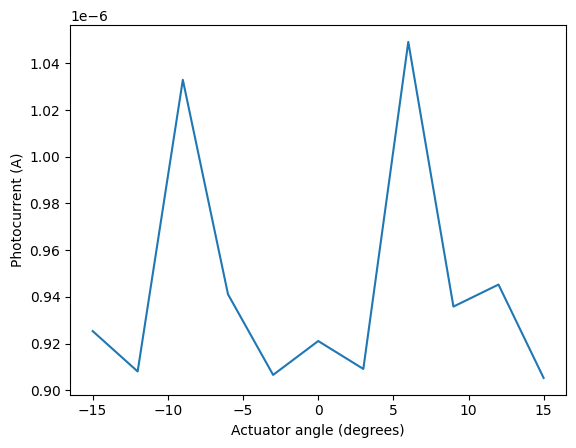

In [24]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\3. Flash Lamp\FlashLamp6.txt", delimiter=',', skiprows=1, usecols=(0,1))

angle = data[:, 0]
photocurrent = data[:, 1]

plt.plot(angle, photocurrent)
plt.xlabel('Actuator angle (degrees)')
plt.ylabel('Photocurrent (A)')
plt.show()